# 02 — Test Estrategia v1: Asian Momentum Breakout

**Objetivo:** Verificar si la regla descubierta (Asian VWAP breakout + momentum) reproduce las entradas del operador real en los 30 trades in-sample.  
**Métrica clave:** Recall — ¿qué % de los 30 trades reales dispara la señal (±60 min)?  
**Sin backtest completo:** No calculamos P&L ni SL/TP. Solo señal direccional.

In [1]:
# ── Celda 1: Imports y carga de datos ──────────────────────────────────────
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Añadir raíz del proyecto al path para imports relativos
PROJECT_ROOT = Path().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from v2.config.settings import DATA_FEATURES, DATA_GROUND_TRUTH
from v2.src.strategies.asian_momentum_v1 import (
    StrategyParams, apply_strategy_to_snapshots,
)

# ── Cargar snapshots ────────────────────────────────────────────────────────
snapshots_path = DATA_FEATURES / 'snapshots_M1.parquet'
snaps_all = pd.read_parquet(snapshots_path)
print(f'snapshots_M1 total: {len(snaps_all):,} filas | {snaps_all.columns.size} columnas')
print(f'Periodo: {snaps_all.index.min()} → {snaps_all.index.max()}')

# ── Cargar trades (solo in-sample) ──────────────────────────────────────────
trades_path = DATA_GROUND_TRUTH / 'trades.parquet'
trades_all = pd.read_parquet(trades_path)
trades_is = trades_all[trades_all['sample'] == 'in_sample'].copy()
trades_is['time_open_utc'] = pd.to_datetime(trades_is['time_open_utc'], utc=True)
print(f'\nTrades in-sample: {len(trades_is)}')
print(f'BUY: {(trades_is["type"]=="BUY").sum()} | SELL: {(trades_is["type"]=="SELL").sum()}')
print(f'Periodo: {trades_is["time_open_utc"].min()} → {trades_is["time_open_utc"].max()}')

# ── Filtrar snapshots al periodo in-sample + 30 min de margen ───────────────
IS_START = trades_is['time_open_utc'].min() - pd.Timedelta(hours=1)
IS_END   = trades_is['time_open_utc'].max() + pd.Timedelta(hours=1)
snaps_is = snaps_all.loc[IS_START:IS_END]
print(f'\nSnapshots filtrados al periodo in-sample: {len(snaps_is):,} filas')

snapshots_M1 total: 59,268 filas | 163 columnas
Periodo: 2026-03-01 22:00:00+00:00 → 2026-04-30 20:58:00+00:00

Trades in-sample: 30
BUY: 20 | SELL: 10
Periodo: 2026-03-19 00:45:58+00:00 → 2026-04-27 01:08:17+00:00

Snapshots filtrados al periodo in-sample: 35,976 filas


Parámetros v1:
  vwap_distance_threshold_pips : 200.0
  bb_pct_b_buy_threshold       : 0.5
  bb_pct_b_sell_threshold      : 0.4
  stoch_k_buy_threshold        : 50.0
  stoch_k_sell_threshold       : 40.0
  min_consecutive_bull_for_buy : 1
  min_consecutive_bear_for_sell: 1
  sesión UTC                   : 22h → 6h

Aplicando estrategia... (puede tardar ~30s en 59k filas)
Señales generadas (tras dedup 30 min): 118
signal
BUY     72
SELL    46


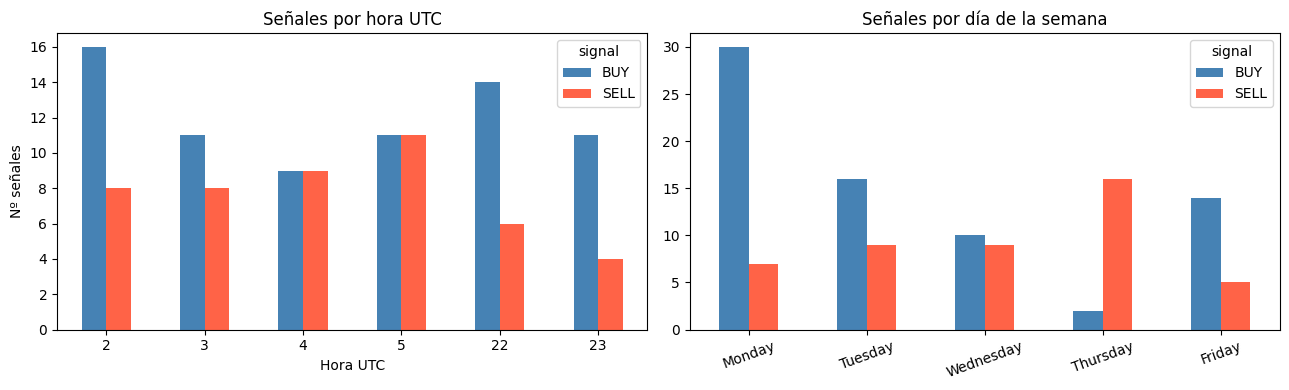

In [2]:
# ── Celda 2: Aplicar estrategia y distribuciones ────────────────────────────
params = StrategyParams()  # parámetros default v1
print('Parámetros v1:')
print(f'  vwap_distance_threshold_pips : {params.vwap_distance_threshold_pips}')
print(f'  bb_pct_b_buy_threshold       : {params.bb_pct_b_buy_threshold}')
print(f'  bb_pct_b_sell_threshold      : {params.bb_pct_b_sell_threshold}')
print(f'  stoch_k_buy_threshold        : {params.stoch_k_buy_threshold}')
print(f'  stoch_k_sell_threshold       : {params.stoch_k_sell_threshold}')
print(f'  min_consecutive_bull_for_buy : {params.min_consecutive_bull_for_buy}')
print(f'  min_consecutive_bear_for_sell: {params.min_consecutive_bear_for_sell}')
print(f'  sesión UTC                   : {params.session_start_utc_hour}h → {params.session_end_utc_hour}h')
print()
print('Aplicando estrategia... (puede tardar ~30s en 59k filas)')

signals_df = apply_strategy_to_snapshots(snaps_is, params, deduplicate_within_minutes=30)
print(f'Señales generadas (tras dedup 30 min): {len(signals_df)}')
print(signals_df['signal'].value_counts().to_string())

# Distribución por hora UTC
signals_df['hour_utc'] = signals_df['timestamp_utc'].dt.hour
signals_df['dow']      = signals_df['timestamp_utc'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

hour_counts = signals_df.groupby(['hour_utc', 'signal']).size().unstack(fill_value=0)
hour_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Señales por hora UTC')
axes[0].set_xlabel('Hora UTC')
axes[0].set_ylabel('Nº señales')
axes[0].tick_params(axis='x', rotation=0)

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
dow_counts = signals_df.groupby(['dow', 'signal']).size().unstack(fill_value=0)
dow_counts = dow_counts.reindex([d for d in dow_order if d in dow_counts.index])
dow_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Señales por día de la semana')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [3]:
# ── Celda 3: Comparación señales vs trades reales ───────────────────────────
TOLERANCE_MINUTES = 60

match_rows = []
for _, trade in trades_is.iterrows():
    t_open = trade['time_open_utc']
    t_type = trade['type']  # 'BUY' o 'SELL'

    # Señales del mismo tipo dentro de la ventana de tolerancia
    same_type = signals_df[signals_df['signal'] == t_type].copy()
    same_type['diff_minutes'] = (
        (same_type['timestamp_utc'] - t_open).dt.total_seconds() / 60
    )
    window = same_type[same_type['diff_minutes'].abs() <= TOLERANCE_MINUTES]

    if len(window) > 0:
        # La señal más cercana en tiempo
        closest = window.loc[window['diff_minutes'].abs().idxmin()]
        match_rows.append({
            'trade_position_id':         trade['position_id'],
            'trade_time_open_utc':       t_open,
            'trade_type':                t_type,
            'trade_price_open':          trade['price_open'],
            'nearest_signal_ts':         closest['timestamp_utc'],
            'nearest_signal_diff_min':   closest['diff_minutes'],
            'match':                     True,
        })
    else:
        match_rows.append({
            'trade_position_id':         trade['position_id'],
            'trade_time_open_utc':       t_open,
            'trade_type':                t_type,
            'trade_price_open':          trade['price_open'],
            'nearest_signal_ts':         pd.NaT,
            'nearest_signal_diff_min':   np.nan,
            'match':                     False,
        })

match_report = pd.DataFrame(match_rows)
print(f'Match report ({len(match_report)} trades):')
print(match_report[['trade_time_open_utc', 'trade_type', 'trade_price_open',
                     'nearest_signal_ts', 'nearest_signal_diff_min', 'match']].to_string())

Match report (30 trades):
         trade_time_open_utc trade_type  trade_price_open         nearest_signal_ts  nearest_signal_diff_min  match
0  2026-03-19 00:45:58+00:00        BUY           4838.09                       NaT                      NaN  False
1  2026-03-19 23:01:23+00:00       SELL           4647.54                       NaT                      NaN  False
2  2026-03-22 23:50:29+00:00       SELL           4465.86                       NaT                      NaN  False
3  2026-03-23 23:37:41+00:00        BUY           4429.37                       NaT                      NaN  False
4  2026-03-24 00:30:01+00:00       SELL           4378.17                       NaT                      NaN  False
5  2026-03-24 23:00:07+00:00        BUY           4484.35 2026-03-24 23:10:00+00:00                 9.883333   True
6  2026-03-25 22:35:20+00:00        BUY           4520.76                       NaT                      NaN  False
7  2026-03-29 23:15:04+00:00       SELL       

In [4]:
# ── Celda 4: Métricas finales ────────────────────────────────────────────────
n_trades    = len(trades_is)
n_buy_real  = (trades_is['type'] == 'BUY').sum()
n_sell_real = (trades_is['type'] == 'SELL').sum()

matched      = match_report[match_report['match']]
missed       = match_report[~match_report['match']]

n_match_buy  = (matched['trade_type'] == 'BUY').sum()
n_match_sell = (matched['trade_type'] == 'SELL').sum()
n_match_tot  = len(matched)

recall_buy   = n_match_buy  / n_buy_real  * 100 if n_buy_real  > 0 else 0
recall_sell  = n_match_sell / n_sell_real * 100 if n_sell_real > 0 else 0
recall_total = n_match_tot  / n_trades    * 100

diffs = matched['nearest_signal_diff_min'].dropna()
drift_mean   = diffs.mean()   if len(diffs) > 0 else np.nan
drift_median = diffs.median() if len(diffs) > 0 else np.nan
drift_p10    = diffs.quantile(0.10) if len(diffs) > 0 else np.nan
drift_p90    = diffs.quantile(0.90) if len(diffs) > 0 else np.nan

print('=' * 50)
print('     EVALUACIÓN ESTRATEGIA v1')
print('=' * 50)
print(f'Trades in-sample          : {n_trades}')
print(f'Señales generadas total   : {len(signals_df)}')
print(f'  BUY                     : {(signals_df["signal"]=="BUY").sum()}')
print(f'  SELL                    : {(signals_df["signal"]=="SELL").sum()}')
print()
print('RECALL (trades reales detectados):')
print(f'  BUYs detectados         : {n_match_buy} / {n_buy_real}  ({recall_buy:.1f}%)')
print(f'  SELLs detectados        : {n_match_sell} / {n_sell_real}  ({recall_sell:.1f}%)')
print(f'  TOTAL recall            : {n_match_tot} / {n_trades}  ({recall_total:.1f}%)')
print()
print('DRIFT TEMPORAL señal→trade (minutos):')
print(f'  Media                   : {drift_mean:.1f} min')
print(f'  Mediana                 : {drift_median:.1f} min')
print(f'  P10 / P90               : {drift_p10:.1f} / {drift_p90:.1f} min')
print('=' * 50)

     EVALUACIÓN ESTRATEGIA v1
Trades in-sample          : 30
Señales generadas total   : 118
  BUY                     : 72
  SELL                    : 46

RECALL (trades reales detectados):
  BUYs detectados         : 10 / 20  (50.0%)
  SELLs detectados        : 2 / 10  (20.0%)
  TOTAL recall            : 12 / 30  (40.0%)

DRIFT TEMPORAL señal→trade (minutos):
  Media                   : -0.1 min
  Mediana                 : 0.1 min
  P10 / P90               : -18.0 / 14.4 min


In [5]:
# ── Celda 5: Análisis de MISSES ──────────────────────────────────────────────
print(f'Trades sin match: {len(missed)}')
if len(missed) == 0:
    print('¡Sin misses! Todos los trades detectados.')
else:
    print(missed[['trade_time_open_utc', 'trade_type', 'trade_price_open']].to_string())
    print()

    # Para cada miss, mostrar qué condición falló en ese timestamp
    COND_COLS = [
        'dist_to_asian_vwap_pips_signed',
        'm15_bb_pct_b',
        'm15_stoch_k',
        'm5_consecutive_bull',
        'm15_consecutive_bear',
        'm15_macd_hist_increasing',
        'm15_rsi_14',
    ]

    miss_snapshots = []
    for _, miss in missed.iterrows():
        t = miss['trade_time_open_utc']
        # Buscar el snapshot más cercano (dentro de ±5 min)
        window = snaps_is.loc[
            t - pd.Timedelta(minutes=5) : t + pd.Timedelta(minutes=5)
        ]
        if len(window) == 0:
            snap_vals = {c: np.nan for c in COND_COLS}
        else:
            snap_vals = window.iloc[0][COND_COLS].to_dict()

        row = {
            'time_open_utc': t,
            'type': miss['trade_type'],
            'price_open': miss['trade_price_open'],
        }
        row.update(snap_vals)
        miss_snapshots.append(row)

    miss_df = pd.DataFrame(miss_snapshots)

    # Marcar qué condiciones fallan para cada miss
    def diagnose(row):
        t = row['type']
        fails = []
        vwap = row.get('dist_to_asian_vwap_pips_signed', np.nan)
        bb   = row.get('m15_bb_pct_b', np.nan)
        stk  = row.get('m15_stoch_k', np.nan)
        cbull= row.get('m5_consecutive_bull', np.nan)
        cbear= row.get('m15_consecutive_bear', np.nan)
        if t == 'BUY':
            if pd.isna(vwap) or vwap <= params.vwap_distance_threshold_pips:
                fails.append(f'vwap={vwap:.0f}≤{params.vwap_distance_threshold_pips:.0f}' if not pd.isna(vwap) else 'vwap=NaN')
            if pd.isna(bb) or bb <= params.bb_pct_b_buy_threshold:
                fails.append(f'bb%={bb:.2f}≤{params.bb_pct_b_buy_threshold}' if not pd.isna(bb) else 'bb%=NaN')
            if pd.isna(stk) or stk <= params.stoch_k_buy_threshold:
                fails.append(f'stoch={stk:.0f}≤{params.stoch_k_buy_threshold:.0f}' if not pd.isna(stk) else 'stoch=NaN')
            if pd.isna(cbull) or cbull < params.min_consecutive_bull_for_buy:
                fails.append(f'cons_bull={cbull:.0f}<{params.min_consecutive_bull_for_buy}' if not pd.isna(cbull) else 'cons_bull=NaN')
        else:
            if pd.isna(vwap) or vwap >= -params.vwap_distance_threshold_pips:
                fails.append(f'vwap={vwap:.0f}≥{-params.vwap_distance_threshold_pips:.0f}' if not pd.isna(vwap) else 'vwap=NaN')
            if pd.isna(bb) or bb >= params.bb_pct_b_sell_threshold:
                fails.append(f'bb%={bb:.2f}≥{params.bb_pct_b_sell_threshold}' if not pd.isna(bb) else 'bb%=NaN')
            if pd.isna(stk) or stk >= params.stoch_k_sell_threshold:
                fails.append(f'stoch={stk:.0f}≥{params.stoch_k_sell_threshold:.0f}' if not pd.isna(stk) else 'stoch=NaN')
            if pd.isna(cbear) or cbear < params.min_consecutive_bear_for_sell:
                fails.append(f'cons_bear={cbear:.0f}<{params.min_consecutive_bear_for_sell}' if not pd.isna(cbear) else 'cons_bear=NaN')
        return '; '.join(fails) if fails else 'OK (sesión o dedup)'

    miss_df['condiciones_fallidas'] = miss_df.apply(diagnose, axis=1)

    print('Diagnóstico de condiciones fallidas:')
    print(miss_df[['time_open_utc', 'type', 'dist_to_asian_vwap_pips_signed',
                   'm15_bb_pct_b', 'm15_stoch_k', 'm5_consecutive_bull',
                   'm15_consecutive_bear', 'condiciones_fallidas']].to_string())

Trades sin match: 18
         trade_time_open_utc trade_type  trade_price_open
0  2026-03-19 00:45:58+00:00        BUY           4838.09
1  2026-03-19 23:01:23+00:00       SELL           4647.54
2  2026-03-22 23:50:29+00:00       SELL           4465.86
3  2026-03-23 23:37:41+00:00        BUY           4429.37
4  2026-03-24 00:30:01+00:00       SELL           4378.17
6  2026-03-25 22:35:20+00:00        BUY           4520.76
7  2026-03-29 23:15:04+00:00       SELL           4478.49
13 2026-04-06 00:29:35+00:00       SELL           4604.33
18 2026-04-09 01:59:26+00:00        BUY           4728.35
19 2026-04-13 00:35:05+00:00        BUY           4679.81
21 2026-04-15 01:14:09+00:00        BUY           4849.67
22 2026-04-15 22:55:08+00:00        BUY           4810.38
23 2026-04-19 23:59:04+00:00       SELL           4754.01
25 2026-04-21 01:55:01+00:00       SELL           4809.77
26 2026-04-21 23:19:56+00:00        BUY           4732.12
27 2026-04-22 23:05:03+00:00       SELL           4

In [10]:
# ── Celda 6: Análisis de señales EXTRA (no matchean trade real) ──────────────
import numpy as np
import pandas as pd
from v2.config.settings import DATA_GROUND_TRUTH, DATA_FEATURES

# Recarga independiente para no depender de variables previas
trades_all = pd.read_parquet(DATA_GROUND_TRUTH / 'trades.parquet')
trades_all['time_open_utc'] = pd.to_datetime(trades_all['time_open_utc'], utc=True)
trades_in = trades_all[trades_all['sample'] == 'in_sample'].copy()
print(f"Trades in-sample cargados: {len(trades_in)}")

# Si signals_df no existe en memoria, cárgalo desde algún lugar — pero debería existir de la celda 2/3
# Intentamos detectar el nombre correcto
import sys
this_module = sys.modules[__name__]
print(f"Variables disponibles que contienen 'signal': {[v for v in dir(this_module) if 'signal' in v.lower()][:10]}")

# Si no está, esto fallará y veremos qué variable usar
# Asumiendo que existe `signals_df` con columnas timestamp_utc, signal
real_times_buy  = trades_in[trades_in['type']=='BUY']['time_open_utc'].values
real_times_sell = trades_in[trades_in['type']=='SELL']['time_open_utc'].values

def is_matched_to_real(sig_ts, sig_type, tol_min=60.0):
    sig_ts = pd.Timestamp(sig_ts).tz_convert('UTC') if pd.Timestamp(sig_ts).tz else pd.Timestamp(sig_ts, tz='UTC')
    real_times = real_times_buy if sig_type == 'BUY' else real_times_sell
    if len(real_times) == 0:
        return False
    diffs_min = np.array([
        (pd.Timestamp(rt) - sig_ts).total_seconds() / 60.0
        for rt in real_times
    ])
    return bool(np.any(np.abs(diffs_min) <= tol_min))

signals_df['matched_to_real'] = signals_df.apply(
    lambda r: is_matched_to_real(r['timestamp_utc'], r['signal']),
    axis=1
)

total = len(signals_df)
matched = signals_df['matched_to_real'].sum()
extras = total - matched

print(f"\n=== ANÁLISIS DE SEÑALES EXTRA ===")
print(f"Total señales generadas:    {total}")
print(f"  Matchean trade real:      {matched}")
print(f"  Señales EXTRA (sin trade):{extras}")
print()

# Distribución temporal de extras
extras_df = signals_df[~signals_df['matched_to_real']].copy()
extras_df['timestamp_utc'] = pd.to_datetime(extras_df['timestamp_utc'], utc=True)
extras_df['hora_utc'] = extras_df['timestamp_utc'].dt.hour
extras_df['dia_semana'] = extras_df['timestamp_utc'].dt.day_name()

print("EXTRAS por hora UTC (cuándo dispara la regla sin que el operador entrara):")
print(extras_df.groupby(['hora_utc', 'signal']).size().unstack(fill_value=0).to_string())
print()
print("EXTRAS por día de semana:")
print(extras_df.groupby(['dia_semana', 'signal']).size().unstack(fill_value=0).to_string())
print()

# Comparación: MATCHES por hora vs EXTRAS por hora
matches_df = signals_df[signals_df['matched_to_real']].copy()
matches_df['hora_utc'] = pd.to_datetime(matches_df['timestamp_utc'], utc=True).dt.hour
print("MATCHES por hora UTC (cuándo la regla SÍ coincidió con un trade real):")
print(matches_df.groupby(['hora_utc', 'signal']).size().unstack(fill_value=0).to_string())

Trades in-sample cargados: 30
Variables disponibles que contienen 'signal': ['signals_df']


TypeError: Cannot subtract tz-naive and tz-aware datetime-like objects.

In [ ]:
# ── Celda 7: Conclusión ──────────────────────────────────────────────────────
print('=' * 50)
print(f'     VEREDICTO HIPÓTESIS v1')
print('=' * 50)
print(f'Recall total: {recall_total:.1f}% ({n_match_tot}/{n_trades} trades detectados)')
print()

if recall_total >= 60:
    print('RESULTADO: Hipótesis v1 viable.')
    print('Acción: Pasar a Fase 2.2 — refinar parámetros y analizar señales extra.')
elif recall_total >= 30:
    print('RESULTADO: Hipótesis v1 parcial.')
    print('Acción: Analizar misses para identificar condición faltante.')
    print('  → ¿La sesión asiática es correcta?')
    print('  → ¿El threshold de VWAP es demasiado restrictivo?')
    print('  → ¿Falta alguna condición del análisis de z-scores?')
else:
    print('RESULTADO: Hipótesis v1 inadecuada.')
    print('Acción: Volver a fase exploratoria. Revisar features principales.')

print()
print('Señales extra (falsos positivos):', len(extras))
ratio = len(extras) / max(n_match_tot, 1)
print(f'Ratio extras/matches: {ratio:.1f}x')
if ratio <= 3:
    print('  → Ratio aceptable (≤3x). La estrategia es selectiva.')
elif ratio <= 10:
    print('  → Ratio moderado (3-10x). Considerar agregar filtros adicionales.')
else:
    print('  → Ratio alto (>10x). Los parámetros son demasiado permisivos.')